In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
equity_weights = pl.read_csv(
    "../Market Caps/Final/coalesced_market_cap_weights.csv"
).rename({"Country": "iso", "Year": "year", "Percentage": "weight"})
bond_weights = pl.read_csv("./Processed/bond_weights.csv").rename(
    {"debt_share": "weight"}
)

equity_universes = pl.read_csv("./Processed/equities_universe.csv")
bond_universes = pl.read_csv("./Processed/bonds_universe.csv")

In [8]:
equity_universe_weights = equity_universes.join(
    equity_weights.select("year", pl.col("iso").alias("iso_foreign"), "weight"),
    on=["year", "iso_foreign"],
).with_columns(
    (pl.col("weight") / pl.col("weight").sum().over("year", "iso_domestic")).alias("normalized_weight")
)

bond_universe_weights = bond_universes.join(
    bond_weights.select("year", pl.col("iso").alias("iso_foreign"), "weight"),
    on=["year", "iso_foreign"],
).with_columns(
    (pl.col("weight") / pl.col("weight").sum().over("year", "iso_domestic")).alias("normalized_weight")
)

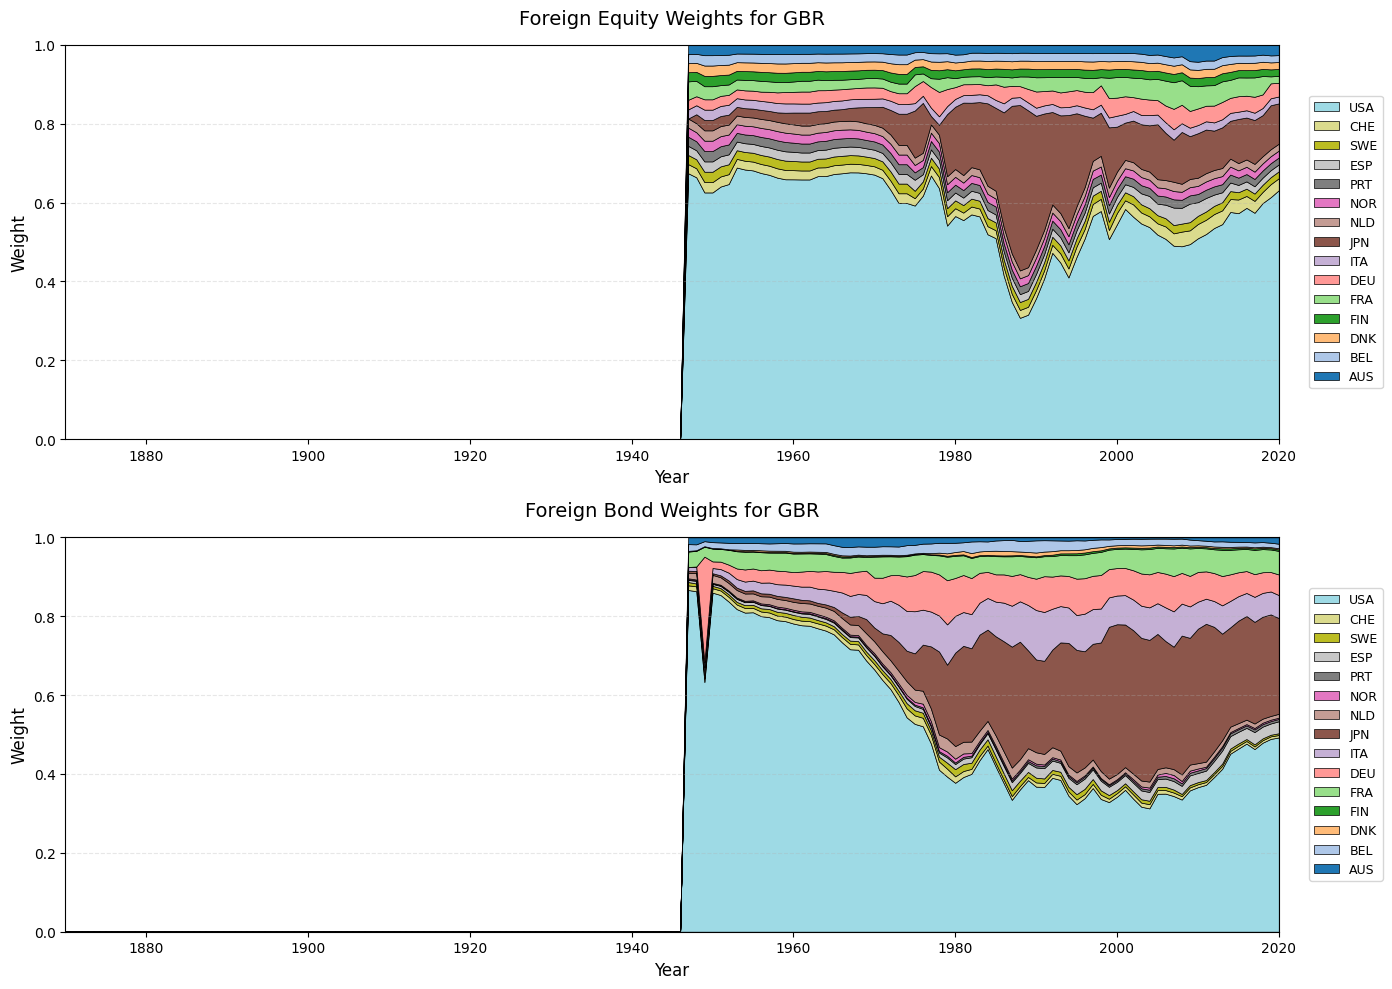


=== Foreign Equity Weight Quality Checks (GBR) ===

1. Yearly weight sums:
   Min: 1.000000
   Max: 1.000000
   Mean: 1.000000
   [OK] All years sum to 1.0

=== Foreign Bond Weight Quality Checks (GBR) ===

1. Yearly weight sums:
   Min: 1.000000
   Max: 1.000000
   Mean: 1.000000
   [OK] All years sum to 1.0


In [15]:
JST_countries = [
    "AUS", "BEL", "CAN", "DNK", "FIN", "FRA", "DEU", "IRL", "ITA",
    "JPN", "NLD", "NOR", "PRT", "ESP", "SWE", "CHE", "GBR", "USA",
]
colors_map = plt.cm.tab20(np.linspace(0, 1, len(JST_countries)))
country_colors = {country: colors_map[i] for i, country in enumerate(JST_countries)}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Filter for the selected domestic country
iso_domestic = "GBR"

# ========== EQUITY WEIGHTS (Top Subplot) ==========
domestic_eq_weights = (
    equity_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .select("year", "iso_foreign", "normalized_weight")
    .pivot(index="year", on="iso_foreign", values="normalized_weight")
    .sort("year")
    .fill_null(0)
)

# create a date spine
date_spine = pl.int_range(
    1870, 2021, eager=True
).to_frame(name="year")

# join to ensure all years are present
domestic_eq_weights = date_spine.join(domestic_eq_weights, on="year", how="left").fill_null(0)

# Get all countries present in the data
countries_in_data = [col for col in domestic_eq_weights.columns if col != "year"]

# Sort like the JST_countries list, with any missing countries at the end
countries_in_data = sorted(countries_in_data, key=lambda x: -JST_countries.index(x) if x in JST_countries else len(JST_countries))

# Map countries to their colors
colors = [country_colors[country] for country in countries_in_data]

# Create stacked area plot for equity
ax1.stackplot(
    domestic_eq_weights["year"], 
    [domestic_eq_weights[country] for country in countries_in_data],
    labels=countries_in_data,
    colors=colors,
    edgecolor='black',
    linewidth=0.5
)

ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, ncol=1)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Weight", fontsize=12)
ax1.set_title(f"Foreign Equity Weights for {iso_domestic}", fontsize=14, pad=15)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.set_ylim(0, 1)
ax1.set_xlim(1870, 2020)

# ========== BOND WEIGHTS (Bottom Subplot) ==========
domestic_bond_weights = (
    bond_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .select("year", "iso_foreign", "normalized_weight")
    .pivot(index="year", on="iso_foreign", values="normalized_weight")
    .sort("year")
    .fill_null(0)
)

# join to ensure all years are present
domestic_bond_weights = date_spine.join(domestic_bond_weights, on="year", how="left").fill_null(0)

# Get all countries present in the bond data
bond_countries_in_data = [col for col in domestic_bond_weights.columns if col != "year"]

# Sort like the JST_countries list, with any missing countries at the end
bond_countries_in_data = sorted(bond_countries_in_data, key=lambda x: -JST_countries.index(x) if x in JST_countries else len(JST_countries))

# Map countries to their colors
bond_colors = [country_colors[country] for country in bond_countries_in_data]

# Create stacked area plot for bonds
ax2.stackplot(
    domestic_bond_weights["year"], 
    [domestic_bond_weights[country] for country in bond_countries_in_data],
    labels=bond_countries_in_data,
    colors=bond_colors,
    edgecolor='black',
    linewidth=0.5
)

ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, ncol=1)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_ylabel("Weight", fontsize=12)
ax2.set_title(f"Foreign Bond Weights for {iso_domestic}", fontsize=14, pad=15)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.set_ylim(0, 1)
ax2.set_xlim(1870, 2020)

plt.tight_layout()
plt.show()

# Quality checks
print(f"\n=== Foreign Equity Weight Quality Checks ({iso_domestic}) ===\n")

yearly_sums = (
    equity_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .group_by("year")
    .agg(pl.col("normalized_weight").sum().alias("total"))
)
print(f"1. Yearly weight sums:")
print(f"   Min: {yearly_sums['total'].min():.6f}")
print(f"   Max: {yearly_sums['total'].max():.6f}")
print(f"   Mean: {yearly_sums['total'].mean():.6f}")

problematic_years = yearly_sums.filter((pl.col("total") < 0.999) | (pl.col("total") > 1.001))
if len(problematic_years) > 0:
    print(f"   WARNING: {len(problematic_years)} years with totals outside [0.999, 1.001]")
else:
    print("   [OK] All years sum to 1.0")

print(f"\n=== Foreign Bond Weight Quality Checks ({iso_domestic}) ===\n")

bond_yearly_sums = (
    bond_universe_weights
    .filter(pl.col("iso_domestic") == iso_domestic)
    .group_by("year")
    .agg(pl.col("normalized_weight").sum().alias("total"))
)
print(f"1. Yearly weight sums:")
print(f"   Min: {bond_yearly_sums['total'].min():.6f}")
print(f"   Max: {bond_yearly_sums['total'].max():.6f}")
print(f"   Mean: {bond_yearly_sums['total'].mean():.6f}")

bond_problematic_years = bond_yearly_sums.filter((pl.col("total") < 0.999) | (pl.col("total") > 1.001))
if len(bond_problematic_years) > 0:
    print(f"   WARNING: {len(bond_problematic_years)} years with totals outside [0.999, 1.001]")
else:
    print("   [OK] All years sum to 1.0")

In [6]:
domestic_eq_weights

year,AUS,BEL,CHE,DEU,DNK,ESP,FIN,FRA,GBR,ITA,NLD,NOR,PRT,SWE,USA
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1870,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2016,0.029827,0.02029,0.032998,0.040351,0.02029,0.02029,0.02029,0.050768,0.02029,0.02029,0.02029,0.02029,0.02029,0.02029,0.643156
2017,0.029717,0.02043,0.033224,0.044566,0.02043,0.02043,0.02043,0.054162,0.02043,0.02043,0.021672,0.02043,0.02043,0.02043,0.632785
2018,0.027182,0.019795,0.031021,0.03778,0.019795,0.019795,0.019795,0.050927,0.019795,0.019795,0.019795,0.019795,0.019795,0.019795,0.655144
